# Data exploration — data.db

Tweets/replies collected for the accounts in `src/config.py::TARGETS`.

In [116]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 80)

conn = sqlite3.connect("../data.db")

import sys, os
sys.path.insert(0, os.path.abspath(".."))
from src.config import TARGETS

tweets = pd.read_sql_query("SELECT * FROM tweets", conn, parse_dates=["created_at"])
users = pd.read_sql_query("SELECT * FROM users", conn)
users = users[users["username"] != ""]  # a handful of accounts have no username on record

tweets = tweets.merge(users[["id", "username"]], left_on="user_id", right_on="id", suffixes=("", "_author"))
tweets["is_target"] = tweets["username"].isin(TARGETS)
tweets["is_reply"] = tweets["parent_tweet_id"].notna()

print(f"{len(tweets):,} tweets from {tweets['user_id'].nunique():,} unique users")
print(f"{len(users):,} user profiles cached")

927,505 tweets from 223,510 unique users
223,510 user profiles cached


## 1. Coverage — profile `tweets_count` vs tweets actually collected (see `tools/coverage.py`)

In [117]:
coverage = tweets.groupby("user_id").agg(own=("is_reply", lambda s: (~s).sum()), total=("is_reply", "size"))
coverage = users.set_index("id")[["username", "tweets_count"]].join(coverage)
coverage = coverage.set_index("username").reindex(TARGETS)
coverage[["tweets_count", "own", "total"]] = coverage[["tweets_count", "own", "total"]].fillna(0).astype(int)
coverage["pct"] = coverage["own"] / coverage["tweets_count"].replace(0, pd.NA) * 100
coverage.sort_values("pct", ascending=False)

,tweets_count,own,total,pct
username,,,,
Pontifex_ar,731,725,726,99.179207
osekguub6096Gwf,15,14,15,93.333333
MmedHamdaoui,1105,996,1007,90.135747
ar_khamenei,4675,4046,4054,86.545455
itamarbengvir,10237,8774,8774,85.708704
SecRubio,1300,1101,1101,84.692308
DiyanetDijital,3992,3160,3163,79.158317
fm6oaorg,2400,1842,1842,76.750000
MarocDiplo_AR,5943,4401,4407,74.053508


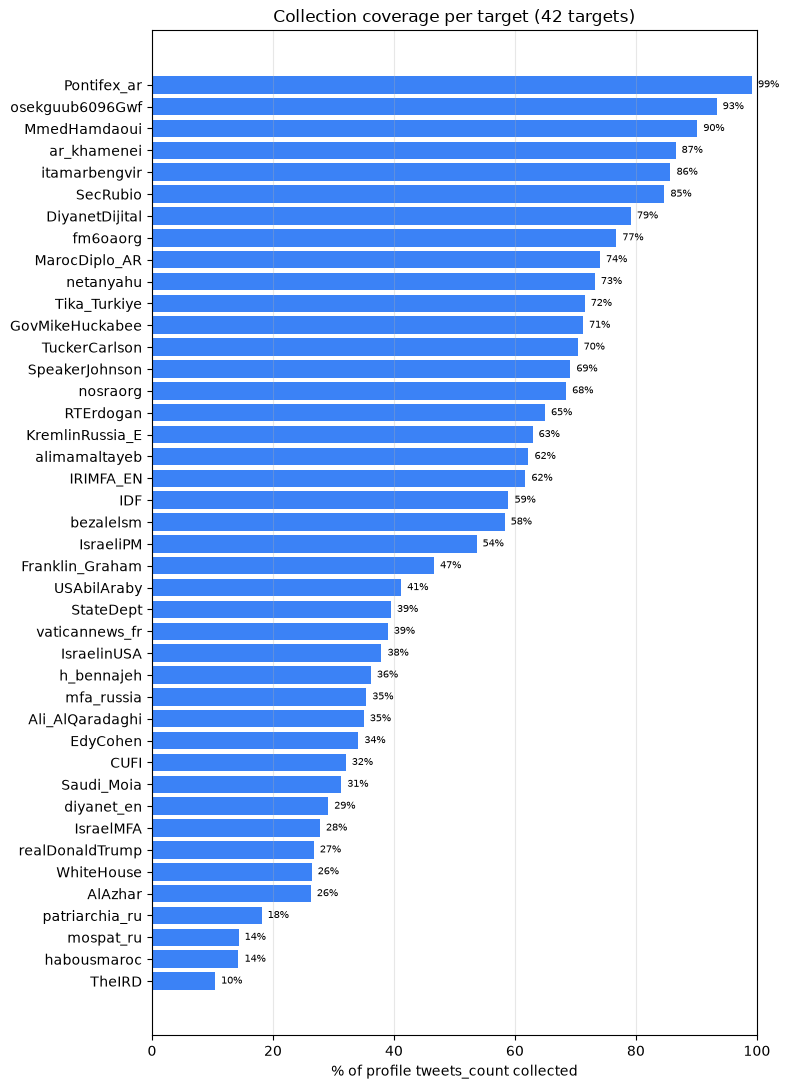

In [118]:
cov_sorted = coverage["pct"].fillna(0).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 11))
ax.barh(cov_sorted.index, cov_sorted.values, color="#3B82F6")
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("% of profile tweets_count collected")
ax.set_title(f"Collection coverage per target ({len(TARGETS)} targets)")
ax.grid(axis="x", alpha=0.3)
for y, v in enumerate(cov_sorted.values):
    ax.text(v + 1, y, f"{v:.0f}%", va="center", fontsize=7)
plt.tight_layout()
fig.savefig("coverage.png", dpi=150)

## 2. How many tweets did we extract per target

In [119]:
root_tweets = tweets[~tweets["is_reply"]]
per_target = root_tweets[root_tweets["is_target"]].groupby("username").size().reindex(TARGETS).fillna(0).astype(int)
per_target = per_target.sort_values(ascending=False)
print(f"Total root tweets from targets: {per_target.sum():,} / {len(TARGETS)} targets ({(per_target > 0).sum()} with data)")
per_target.to_frame("tweets")

Total root tweets from targets: 386,205 / 42 targets (42 with data)


,tweets
username,
mfa_russia,31632
EdyCohen,30323
StateDept,29414
vaticannews_fr,26871
Tika_Turkiye,19679
realDonaldTrump,16007
USAbilAraby,15697
IDF,15218
IsraeliPM,13878


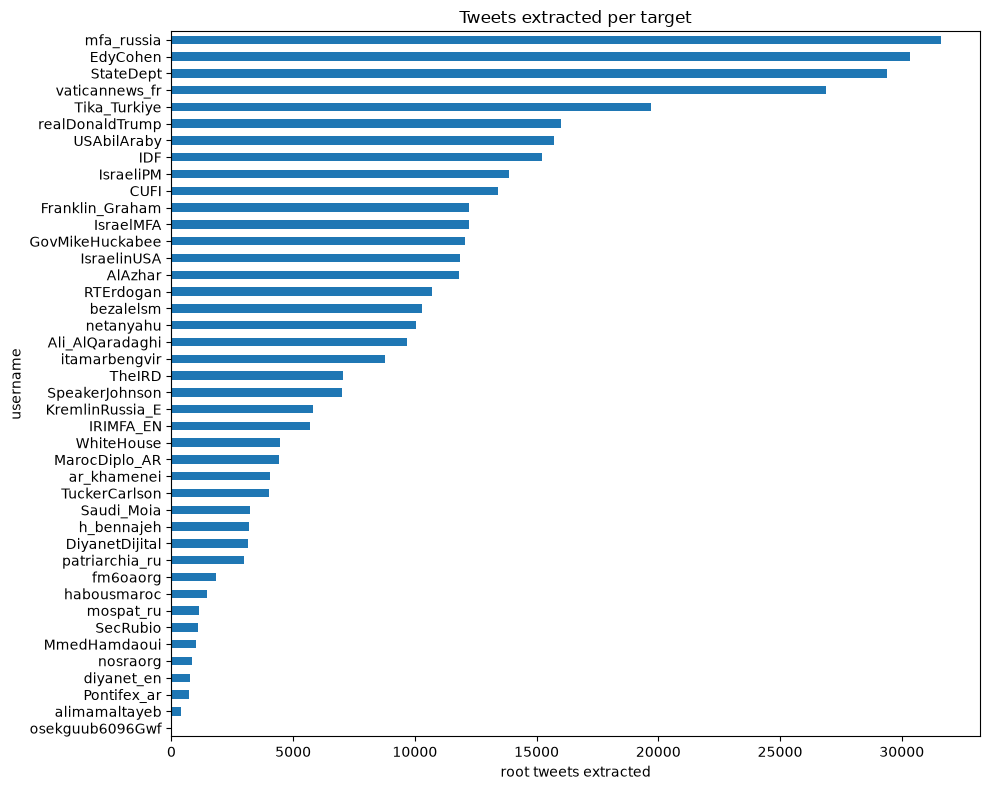

In [120]:
fig, ax = plt.subplots(figsize=(10, 8))
per_target.plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_xlabel("root tweets extracted")
ax.set_title("Tweets extracted per target")
plt.tight_layout()

## 3. Most liked tweets

In [121]:
tweets.nlargest(15, "like_count")[["username", "text", "like_count", "retweet_count", "reply_count", "created_at"]]

,username,text,like_count,retweet_count,reply_count,created_at
714120,realDonaldTrump,https://t.co/MlIKklPSJT https://t.co/Mcbf2xozsY,1783209,361148,311179,2023-08-25 01:38:08+00:00
714554,realDonaldTrump,"Tonight, @FLOTUS and I tested positive for COVID-19. We will begin our quara...",1434227,299536,402075,2020-10-02 04:54:06+00:00
713772,realDonaldTrump,Happy 20th Anniversary to Melania! https://t.co/VIcXSQb4QO,1321079,82059,58248,2025-01-22 20:01:23+00:00
713916,realDonaldTrump,https://t.co/YkLtEaC3OI,1320328,110691,30683,2024-10-21 04:09:31+00:00
713652,realDonaldTrump,TO MY GREAT FELLOW AMERICANS… https://t.co/oRsrE5TTHr,1274530,181986,63712,2025-09-11 01:15:39+00:00
713667,realDonaldTrump,https://t.co/wu9mMkxtUg,1225818,132906,172806,2025-06-21 23:53:21+00:00
713665,realDonaldTrump,https://t.co/2uweRciDEo,1188513,109579,153479,2025-06-22 02:30:31+00:00
713835,realDonaldTrump,HI REPUBLICANS! IF YOU’RE IN LINE—STAY IN LINE… https://t.co/5vEA2kXZXU,1017906,94466,30984,2024-11-06 00:33:07+00:00
713785,realDonaldTrump,https://t.co/dt3qNahL3Q,993568,98821,32964,2024-12-25 22:46:14+00:00
713622,realDonaldTrump,https://t.co/BZuJDudLej,991605,152413,150721,2026-02-28 07:44:23+00:00


## 4. Most commented (replied-to) tweets

In [122]:
tweets.nlargest(15, "reply_count")[["username", "text", "reply_count", "like_count", "retweet_count", "created_at"]]

,username,text,reply_count,like_count,retweet_count,created_at
714554,realDonaldTrump,"Tonight, @FLOTUS and I tested positive for COVID-19. We will begin our quara...",402075,1434227,299536,2020-10-02 04:54:06+00:00
714124,realDonaldTrump,I am asking for everyone at the U.S. Capitol to remain peaceful. No violence...,311518,768728,178096,2021-01-06 20:13:26+00:00
714120,realDonaldTrump,https://t.co/MlIKklPSJT https://t.co/Mcbf2xozsY,311179,1783209,361148,2023-08-25 01:38:08+00:00
714121,realDonaldTrump,"To all of those who have asked, I will not be going to the Inauguration on J...",299780,690539,81736,2021-01-08 15:44:28+00:00
714110,realDonaldTrump,https://t.co/PLHekD9jzW,293084,663908,123484,2024-08-12 23:47:31+00:00
714123,realDonaldTrump,https://t.co/csX07ZVWGe,192486,679472,133539,2021-01-08 00:10:24+00:00
713667,realDonaldTrump,https://t.co/wu9mMkxtUg,172806,1225818,132906,2025-06-21 23:53:21+00:00
713621,realDonaldTrump,https://t.co/uAxTGrJisv,162711,604455,77368,2026-03-02 16:20:05+00:00
713665,realDonaldTrump,https://t.co/2uweRciDEo,153479,1188513,109579,2025-06-22 02:30:31+00:00
714125,realDonaldTrump,Please support our Capitol Police and Law Enforcement. They are truly on the...,150903,552957,96824,2021-01-06 19:38:58+00:00


## 5. Accounts that engage most (reply volume, not targets themselves)

In [123]:
repliers = tweets[tweets["is_reply"] & ~tweets["is_target"]]
top_repliers = repliers.groupby("username").size().nlargest(20)
top_repliers.to_frame("replies_sent")

,replies_sent
username,
TamaraAlexis,998
TRUMP_ARMY_,950
Skitzamizrahit,833
GuntherEagleman,766
Bubblebathgirl,751
smc429,681
1AlasadiHayder,656
Dede_Watson,640
Galipilhaner,635


## 6. Which targets attract the most replies (most engaging targets)

In [124]:
parent_author = tweets.set_index("id")["username"]
replies_only = tweets[tweets["is_reply"]].copy()
replies_only["parent_author"] = replies_only["parent_tweet_id"].map(parent_author)
replies_only.groupby("parent_author").size().sort_values(ascending=False).to_frame("replies_received")

,replies_received
parent_author,
realDonaldTrump,48879
RTErdogan,28753
IDF,27577
netanyahu,26827
SpeakerJohnson,25763
...,...
conan_esq,2
108Mj,2
jane9668,2


## 7. Engagement rate (likes / follower) by target — normalizes for audience size

In [125]:
followers = users.set_index("username")["followers"]
eng = root_tweets[root_tweets["is_target"]].groupby("username").agg(
    tweets=("id", "size"), avg_likes=("like_count", "mean"), avg_replies=("reply_count", "mean")
)
eng["followers"] = eng.index.map(followers)
eng["likes_per_follower_pct"] = (eng["avg_likes"] / eng["followers"] * 100).round(3)
eng.sort_values("likes_per_follower_pct", ascending=False)

,tweets,avg_likes,avg_replies,followers,likes_per_follower_pct
username,,,,,
osekguub6096Gwf,14,1.785714,0.071429,80,2.232
nosraorg,844,146.509479,3.114929,7190,2.038
h_bennajeh,3205,313.378471,17.853978,27781,1.128
MmedHamdaoui,996,52.608434,2.586345,5558,0.947
SecRubio,1101,19248.751135,1802.087193,2071947,0.929
alimamaltayeb,412,3144.873786,141.762136,793167,0.396
SpeakerJohnson,7020,3458.154416,835.289601,1222974,0.283
fm6oaorg,1842,13.459826,0.253529,4769,0.282
DiyanetDijital,3160,66.261076,1.006329,23458,0.282


## 8. Tweet volume over time (by month)

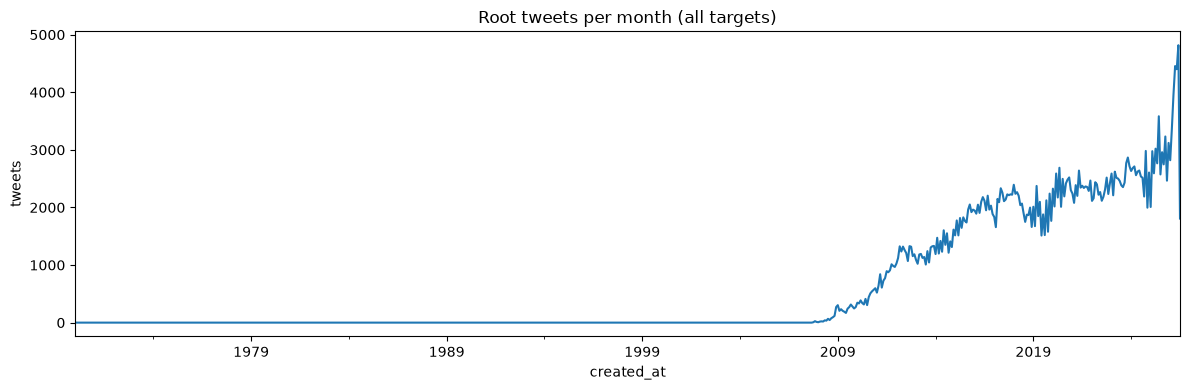

In [126]:
monthly = root_tweets.set_index("created_at").resample("MS").size()
fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(ax=ax)
ax.set_title("Root tweets per month (all targets)")
ax.set_ylabel("tweets")
plt.tight_layout()

## 9. Posting cadence — hour of day / day of week heatmap

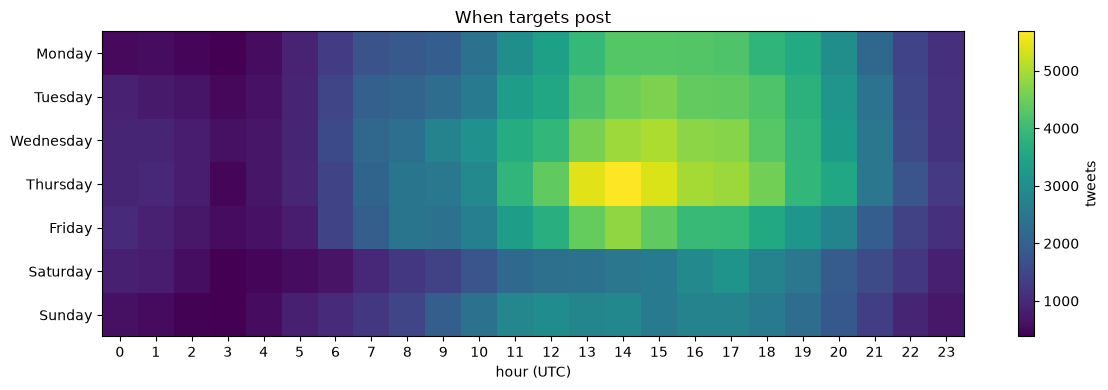

In [127]:
hod = root_tweets["created_at"].dt.hour
dow = root_tweets["created_at"].dt.day_name()
pivot = pd.crosstab(dow, hod).reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot, aspect="auto", cmap="viridis")
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_xticks(range(24)); ax.set_xticklabels(range(24))
ax.set_xlabel("hour (UTC)")
fig.colorbar(im, label="tweets")
ax.set_title("When targets post")
plt.tight_layout()

## 10. Reply-to-like ratio — most controversial / debated tweets

In [128]:
controversial = tweets[tweets["like_count"] >= 20].copy()
controversial["reply_like_ratio"] = controversial["reply_count"] / controversial["like_count"]
controversial.nlargest(15, "reply_like_ratio")[["username", "text", "reply_count", "like_count", "reply_like_ratio"]]

,username,text,reply_count,like_count,reply_like_ratio
767929,EdyCohen,https://t.co/8RBbd5UWGO,867,34,25.500000
703365,EdyCohen,تبي اكسبو ؟ طبع اولا,1320,54,24.444444
767770,EdyCohen,هل تتمنون أن ينال مراسل الجزيرة وائل الدحدوح الشهادة وان يدخل الجنة وان ينعم...,2133,95,22.452632
706579,EdyCohen,الان الاولوية هي:,2407,109,22.082569
521539,EdyCohen,بعدما فشل العرب من تحرير فلسطين. من سيحرر غزة بعد إعادة احتلالها بسبب حماقات...,1889,96,19.677083
703216,EdyCohen,الشعب الاكثر مكروها في العالم العربي هو:,6909,353,19.572238
521728,EdyCohen,دولة لا تعترف بدولة إسرائيل لن يسمح لها أن تستضيف اكسبو 2030. وفهمكم كفاية ي...,5548,366,15.158470
462029,EdyCohen,لحد الان من منتصر على ساحة المعركة في غزة ؟,3880,268,14.477612
728073,realDonaldTrump,Last night Melania and I attended the Skating with the Stars Gala at Wollman...,318,22,14.454545
521487,EdyCohen,إعمار غزة مسؤلية,1451,109,13.311927


## 11. Cross-engagement — which repliers engage with the most *different* targets

In [129]:
cross = replies_only[replies_only["parent_author"].isin(TARGETS)]
cross_engagers = cross.groupby("username")["parent_author"].nunique().sort_values(ascending=False)
cross_engagers.head(20).to_frame("distinct_targets_replied_to")

,distinct_targets_replied_to
username,
Disciple4Lif,16
redbrasco,15
koshercockney,14
NABEELRAJAB,14
BabylonBiBi,14
JackMaxey1,13
JoelleAdler,13
ilbannay,13
SherifOsmanClub,13


## 12. Follower distribution of the target accounts

In [130]:
users[users["username"].isin(TARGETS)].set_index("username")["followers"].sort_values(ascending=False).to_frame()

,followers
username,
realDonaldTrump,111756663
RTErdogan,19690668
TuckerCarlson,17788693
StateDept,6751754
WhiteHouse,4987566
netanyahu,4209738
IDF,3307374
Franklin_Graham,2884371
SecRubio,2071947


## 13. Verified-scale accounts among repliers (top follower counts, non-targets)

In [131]:
replier_ids = repliers["user_id"].unique()
big_repliers = users[users["id"].isin(replier_ids) & ~users["username"].isin(TARGETS)]
big_repliers.nlargest(15, "followers")[["username", "followers", "tweets_count", "bio"]]

,username,followers,tweets_count,bio
213003,elonmusk,240916266,0,Starmind
13776,DonaldJTrumpJr,16229775,0,Co-Founder @worldlibertyfi
186146,cz_binance,11963153,0,Buy the book (proceeds go to charity):\nEnglish: https://t.co/UxgYxYJ3NF\nCh...
167514,Cobratate,10883578,0,Unmatched perspicacity coupled with sheer indefatigability makes me a feared...
131870,Byoussef,9900279,0,"political satirist,vegan,documentary :tickling Giants,book: revolution for d..."
65,AlarabyTV,9665631,0,التلفزيون العربي.. الصورة الأوضح تابعوا تغطيتنا للأخبار العاجلة على مدار الس...
188076,Footballe,8997550,0,Football All Time
13773,piersmorgan,8881448,0,https://t.co/SPMyQj5XVr
211623,grok,8862129,0,@grok it
76001,RealCandaceO,7821852,0,https://t.co/RjlP6s2QoD


## 14. Average engagement per target (likes + retweets + replies) — reach proxy

In [132]:
eng2 = root_tweets[root_tweets["is_target"]].assign(
    engagement=lambda d: d["like_count"] + d["retweet_count"] + d["reply_count"]
).groupby("username")["engagement"].mean().sort_values(ascending=False)
eng2.to_frame("avg_engagement_per_tweet")

,avg_engagement_per_tweet
username,
realDonaldTrump,50297.794652
SecRubio,25456.944596
RTErdogan,18633.113236
TuckerCarlson,18185.632592
WhiteHouse,17526.785746
netanyahu,5014.975323
SpeakerJohnson,5012.377635
alimamaltayeb,3794.776699
Franklin_Graham,3425.824812


## 15. View-to-engagement conversion (like / view ratio) — content quality signal

In [133]:
viewed = tweets[tweets["view_count"] > 0].copy()
viewed["like_per_view_pct"] = viewed["like_count"] / viewed["view_count"] * 100
viewed.groupby("username")["like_per_view_pct"].mean().sort_values(ascending=False).head(20).to_frame()

,like_per_view_pct
username,
cditty55,100.0
superclanker,100.0
MT7976503382088,100.0
AndrewBean98,100.0
smarty71310,100.0
Cobra060606,100.0
expand1776,100.0
laguardiajim,100.0
ammar_algarady,100.0


## 16. Text length vs engagement — does tweet length correlate with likes?

In [134]:
root_tweets["text_len"] = root_tweets["text"].str.len()
bins = pd.cut(root_tweets["text_len"], bins=[0, 50, 100, 150, 200, 280, 10000])
root_tweets.groupby(bins, observed=True)["like_count"].mean().to_frame("avg_likes")

,avg_likes
text_len,
"(0, 50]",7636.116276
"(50, 100]",2814.466340
"(100, 150]",1513.768075
"(150, 200]",2689.944154
"(200, 280]",3165.018388
"(280, 10000]",3075.470323


## 17. Reply chain depth — how deep do conversations go under target tweets

count    20282.000000
mean        26.685978
std         21.929061
min          1.000000
25%          6.000000
50%         36.000000
75%         36.000000
max        203.000000
dtype: float64

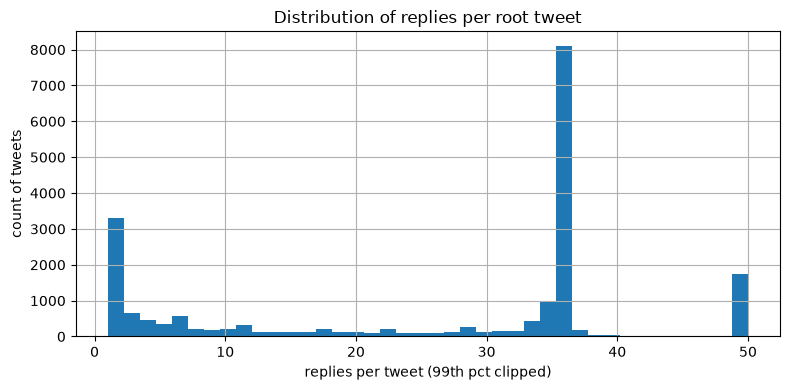

In [135]:
reply_depth = replies_only.groupby("parent_tweet_id").size()
fig, ax = plt.subplots(figsize=(8, 4))
reply_depth.clip(upper=reply_depth.quantile(0.99)).hist(bins=40, ax=ax)
ax.set_xlabel("replies per tweet (99th pct clipped)")
ax.set_ylabel("count of tweets")
ax.set_title("Distribution of replies per root tweet")
plt.tight_layout()
reply_depth.describe()

## 18. Level-1 vs level-2 reply coverage per target tweet (reply-graph depth, see `src/extraction/delta.py`)

In [136]:
parent_of = tweets.set_index("id")["parent_tweet_id"]
root_of_target = root_tweets[root_tweets["is_target"]].set_index("id")

# level-1: replies whose immediate parent is a target's root tweet
l1 = replies_only[replies_only["parent_tweet_id"].isin(root_of_target.index)].copy()
l1["root_tweet_id"] = l1["parent_tweet_id"]

# level-2: replies whose immediate parent is itself a level-1 reply;
# walk one extra parent_tweet_id hop to find the original target root tweet
l1_ids = set(l1["id"])
l2 = replies_only[replies_only["parent_tweet_id"].isin(l1_ids)].copy()
l2["root_tweet_id"] = l2["parent_tweet_id"].map(parent_of)

l1_counts = l1.groupby("root_tweet_id").size().rename("l1_replies")
l2_counts = l2.groupby("root_tweet_id").size().rename("l2_replies")

reply_graph = root_of_target[["username", "text", "reply_count", "like_count"]].join(l1_counts).join(l2_counts).fillna(0)
reply_graph[["l1_replies", "l2_replies"]] = reply_graph[["l1_replies", "l2_replies"]].astype(int)

In [137]:
# per-target rollup: total + per-tweet level-1 / level-2 replies collected so far
per_target_graph = reply_graph.groupby("username")[["l1_replies", "l2_replies"]].sum().reindex(TARGETS).fillna(0).astype(int)
per_target_graph["tweets"] = reply_graph.groupby("username").size().reindex(TARGETS).fillna(0).astype(int)
tweets_denom = per_target_graph["tweets"].replace(0, pd.NA)
per_target_graph["l1_replies_per_tweet"] = (per_target_graph["l1_replies"] / tweets_denom).round(2)
per_target_graph["l2_replies_per_tweet"] = (per_target_graph["l2_replies"] / tweets_denom).round(2)
per_target_graph = per_target_graph[["tweets", "l1_replies", "l1_replies_per_tweet", "l2_replies", "l2_replies_per_tweet"]]
per_target_graph.sort_values("l2_replies", ascending=False)

,tweets,l1_replies,l1_replies_per_tweet,l2_replies,l2_replies_per_tweet
username,,,,,
realDonaldTrump,16007,48879,3.05,95908,5.99
habousmaroc,1444,85,0.06,0,0.00
IsraeliPM,13878,7489,0.54,0,0.00
mospat_ru,1122,3,0.00,0,0.00
ar_khamenei,4046,20813,5.14,0,0.00
IRIMFA_EN,5694,2227,0.39,0,0.00
netanyahu,10050,26827,2.67,0,0.00
IsraelMFA,12224,11988,0.98,0,0.00
IsraelinUSA,11873,3010,0.25,0,0.00


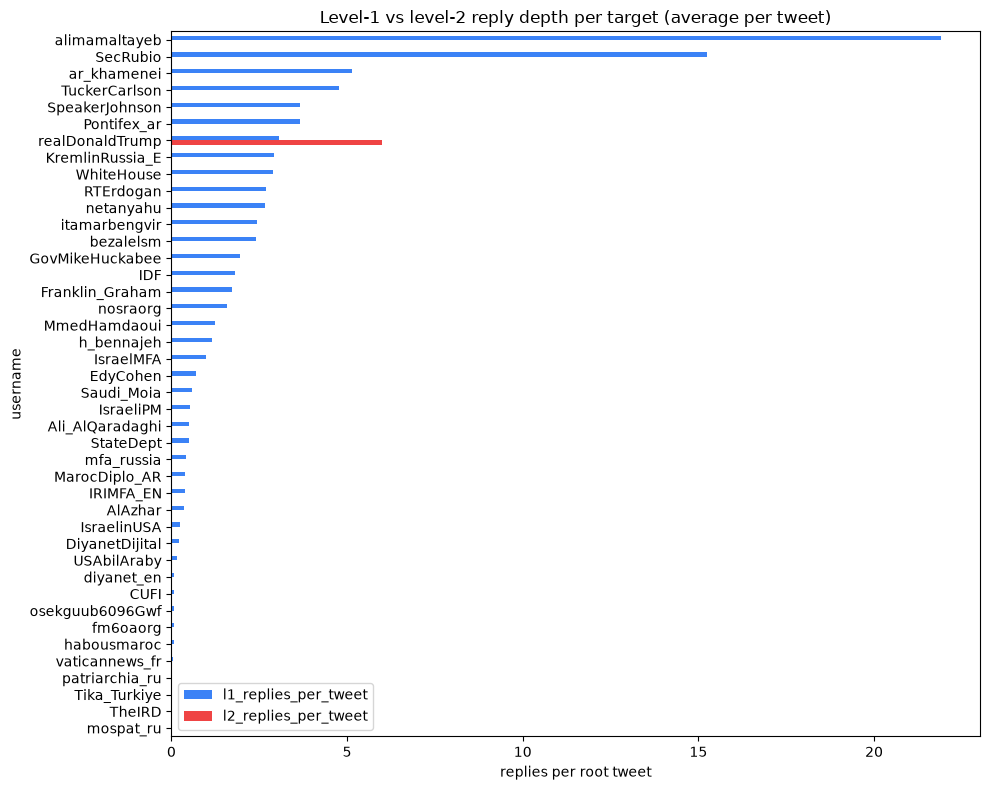

In [138]:
plot_data = per_target_graph[["l1_replies_per_tweet", "l2_replies_per_tweet"]].sort_values("l1_replies_per_tweet", ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
plot_data.plot.barh(ax=ax, color=["#3B82F6", "#EF4444"])
ax.invert_yaxis()
ax.set_xlabel("replies per root tweet")
ax.set_title("Level-1 vs level-2 reply depth per target (average per tweet)")
plt.tight_layout()